In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
def wrangle(path):
    # Load data
    df = pd.read_csv(path, skiprows=1)

    # Convert first column to datetime 
    df['date'] = pd.to_datetime(df['unix'], unit = "s")
    df = df.sort_values(by='date', ascending=True)

    # Set index
    df.set_index('date', inplace=True)

    # Drop columns
    df = df.drop(columns=['unix', 'symbol'])

    return df

In [3]:
df = wrangle("/Users/alexzheng/Developer/GitHub/EC331-project/data/4.0/Bitstamp_BTCUSD_2024_minute.csv")

In [4]:
df.count()

open          565687
high          565687
low           565687
close         565687
Volume BTC    565687
Volume USD    565687
dtype: int64

In [5]:
df

,open,high,low,close,Volume BTC,Volume USD
date,,,,,,
2024-01-01 00:00:00,42258.0,42268.0,42257,42268,1.049735,44370.180382
2024-01-01 00:01:00,42268.0,42283.0,42268,42283,2.291939,96910.057583
2024-01-01 00:02:00,42288.0,42298.0,42288,42298,1.569998,66407.775404
2024-01-01 00:03:00,42297.0,42353.0,42297,42353,4.883858,206846.034909
2024-01-01 00:04:00,42359.0,42375.0,42359,42375,5.742427,243335.353448
...,...,...,...,...,...,...
2025-02-10 23:39:00,97347.0,97347.0,97339,97339,0.005864,570.787135
2025-02-10 23:40:00,97339.0,97339.0,97336,97336,0.016011,1558.430149
2025-02-10 23:41:00,97340.0,97346.0,97340,97346,0.001320,128.496720


In [6]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 565687 entries, 2024-01-01 00:00:00 to 2025-02-10 23:43:00
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   open        565687 non-null  float64
 1   high        565687 non-null  float64
 2   low         565687 non-null  int64  
 3   close       565687 non-null  int64  
 4   Volume BTC  565687 non-null  float64
 5   Volume USD  565687 non-null  float64
dtypes: float64(4), int64(2)
memory usage: 30.2 MB
None
                open           high            low          close  \
count  565687.000000  565687.000000  565687.000000  565687.000000   
mean    69214.428697   69234.485089   69194.118437   69214.433004   
std     17159.042324   17163.854177   17153.532373   17158.526914   
min     38515.000000   38525.000000   38505.000000   38508.000000   
25%     59820.000000   59841.000000   59802.000000   59820.500000   
50%     65549.000000   65564.000000   65531.000000

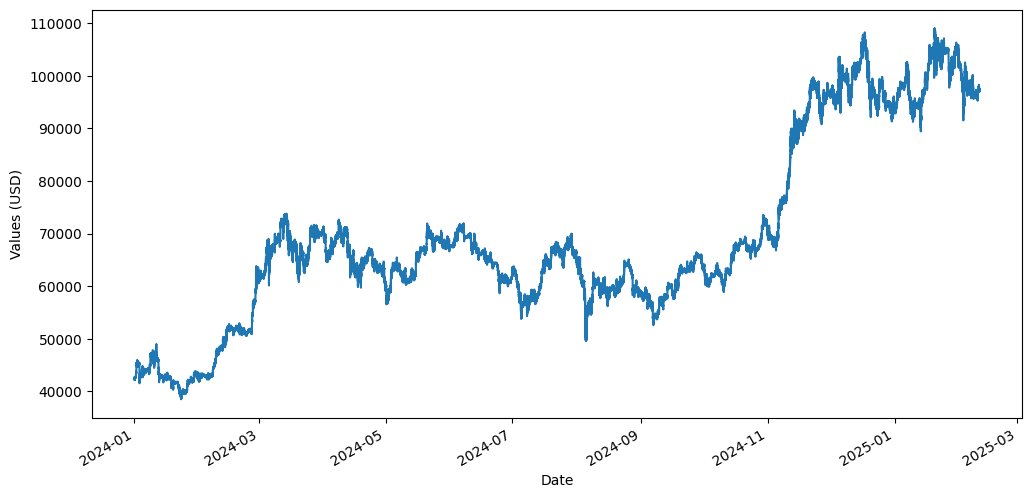

In [7]:
# Plot the 'close' prices
df['close'].plot(figsize=(12, 6))
plt.xlabel('Date')
plt.ylabel('Values (USD)');

<Axes: xlabel='date'>

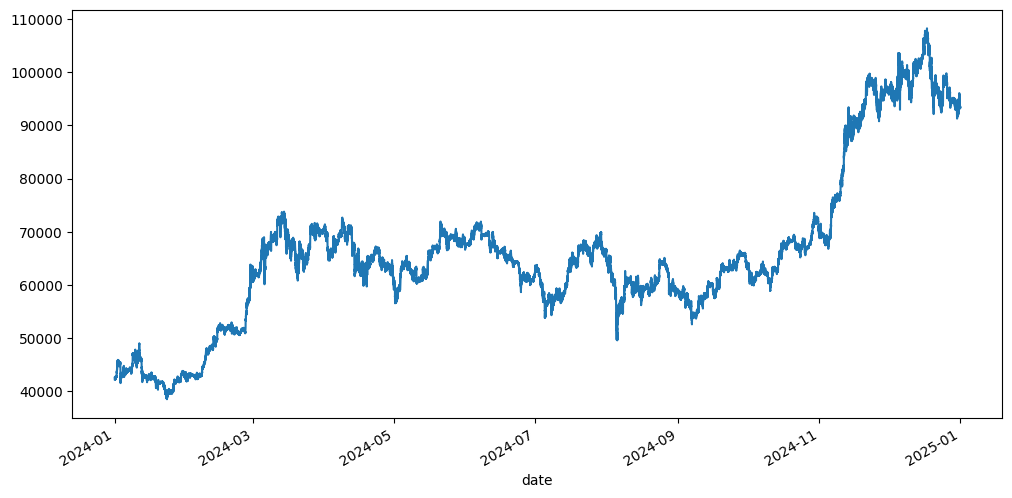

In [8]:
# Select data for 2024
data_2024 = df[df.index.year == 2024]
data_2024.tail(60)

data_2024['close'].plot(figsize=(12, 6))

In [9]:
df.to_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/4.0/Bitcoin_data.csv")